# MNIST Handwritten Digit Classification using Neural Networks

**Project**: Classify handwritten digits (0–9) using Machine Learning & Deep Learning.

**Dataset**: MNIST — 70,000 grayscale images (28×28 pixels) of handwritten digits

**Models Compared**: Baseline Dense NN · CNN · Enhanced CNN with Data Augmentation

---

### Table of Contents

| Step | Section |
|------|---------|
| 1 | Setup & Imports |
| 2 | Data Loading |
| 3 | EDA — Sample Image Grid |
| 4 | EDA — Class Distribution |
| 5 | EDA — Pixel Intensity Analysis |
| 6 | EDA — Average Digit Visualization |
| 7 | EDA — Insights Summary |
| 8 | Data Preprocessing |
| 9 | Model 1: Baseline Dense NN |
| 10 | Model 2: CNN |
| 11 | Model 3: Enhanced CNN + Data Augmentation |
| 12 | Training Visualization |
| 13 | Comprehensive Evaluation |
| 14 | Model Comparison |
| 15 | Misclassified Image Analysis |
| 16 | Visual Prediction Grid |
| 17 | Predictive System & Model Save |
| 18 | Conclusion |

---
## Step 1: Setup & Imports

Import all necessary libraries for data handling, visualization, preprocessing, machine learning, and deep learning.

In [1]:
# Step 1: Import Dependencies

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sklearn - Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Plotting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print("\n All libraries imported successfully!")

TensorFlow version: 2.20.0
NumPy version: 2.1.3

 All libraries imported successfully!


---
## Step 2: Data Loading

Load the MNIST dataset from Keras. It contains **70,000 grayscale images** of handwritten digits (0–9), each of size **28×28 pixels**.

- **Training set**: 60,000 images
- **Test set**: 10,000 images
- **Pixel values**: 0–255 (grayscale intensity)

In [2]:
# Step 2: Load MNIST Dataset

(X_train_raw, Y_train), (X_test_raw, Y_test) = mnist.load_data()

print("=" * 60)
print("  MNIST HANDWRITTEN DIGIT DATASET")
print("=" * 60)
print(f"  Training samples:  {X_train_raw.shape[0]}")
print(f"  Test samples:      {X_test_raw.shape[0]}")
print(f"  Image dimensions:  {X_train_raw.shape[1]} x {X_train_raw.shape[2]} pixels")
print(f"  Channels:          1 (Grayscale)")
print(f"  Pixel range:       [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"  Number of classes: {len(np.unique(Y_train))} (digits 0-9)")
print(f"  Data type:         {X_train_raw.dtype}")
print("=" * 60)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MNIST HANDWRITTEN DIGIT DATASET
  Training samples:  60000
  Test samples:      10000
  Image dimensions:  28 x 28 pixels
  Channels:          1 (Grayscale)
  Pixel range:       [0, 255]
  Number of classes: 10 (digits 0-9)
  Data type:         uint8


---
## Step 3: EDA — Sample Image Grid

Visualize **5 sample images for each digit** (0–9) to understand what the handwritten digits look like.

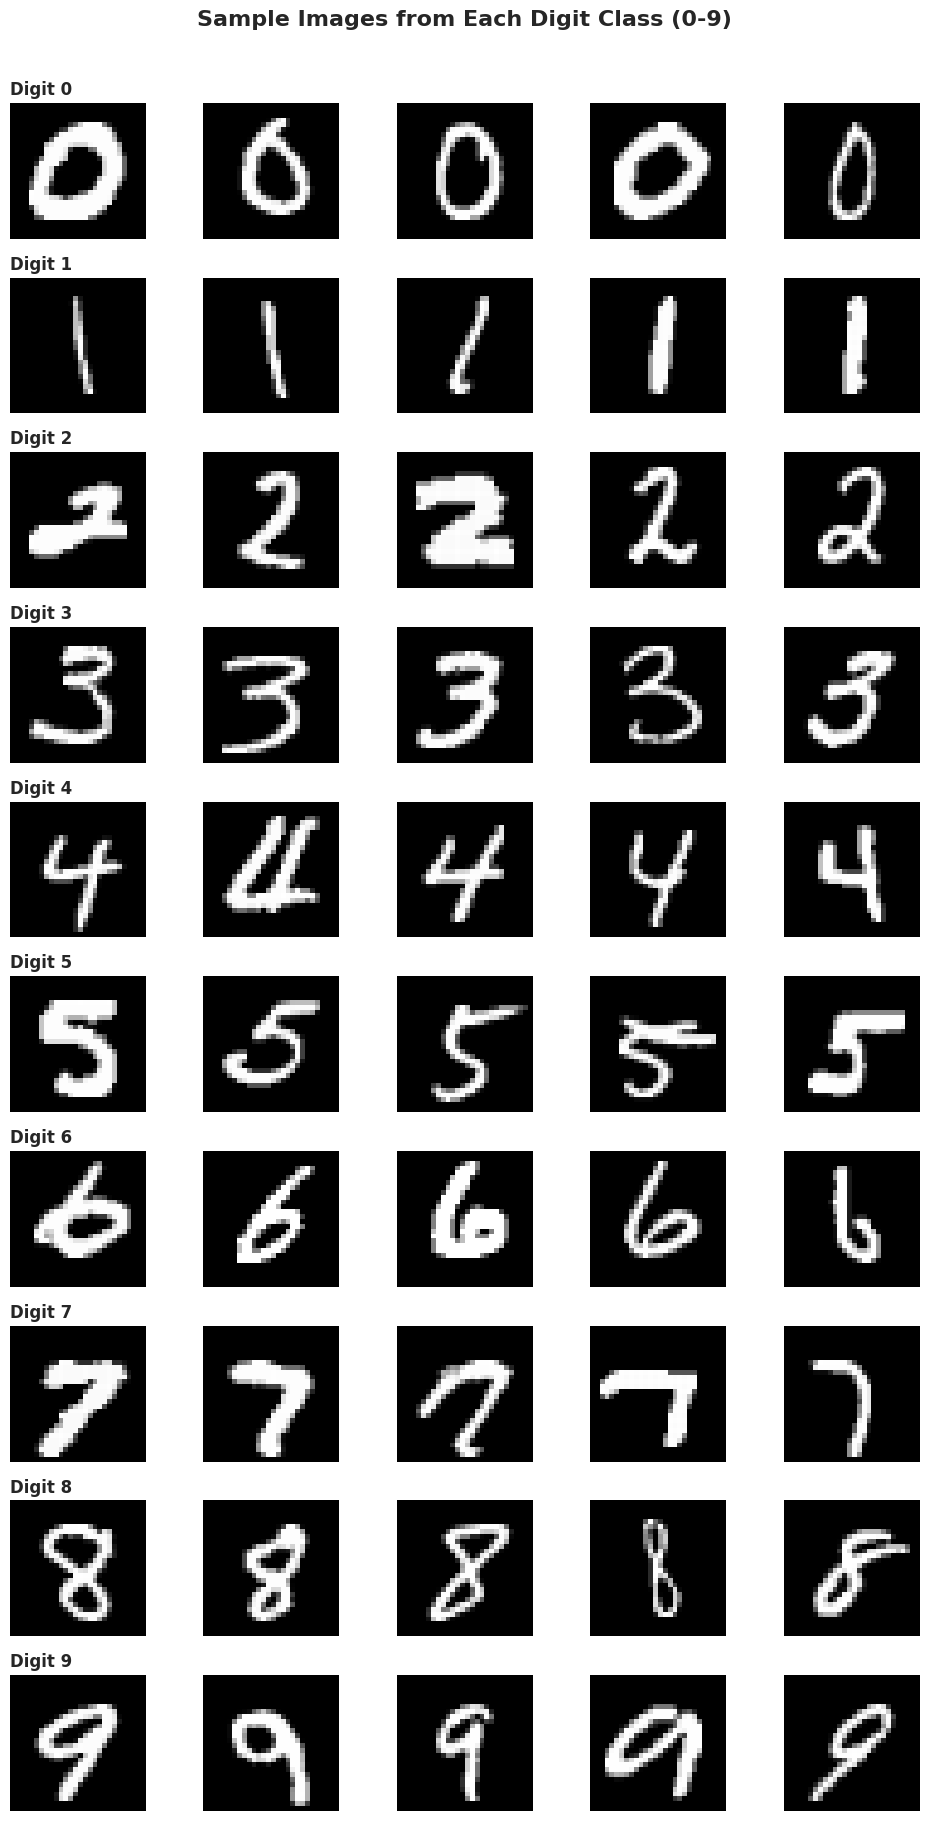

In [3]:
# Display 5 samples per digit (10x5 grid)
fig, axes = plt.subplots(10, 5, figsize=(10, 18))

for digit in range(10):
    # Find indices of this digit
    digit_indices = np.where(Y_train == digit)[0]
    # Pick 5 random samples
    samples = np.random.choice(digit_indices, 5, replace=False)

    for j, idx in enumerate(samples):
        axes[digit, j].imshow(X_train_raw[idx], cmap='gray')
        axes[digit, j].axis('off')
        if j == 0:
            axes[digit, j].set_title(f'Digit {digit}', fontsize=12, fontweight='bold', loc='left')

plt.suptitle('Sample Images from Each Digit Class (0-9)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 4: EDA — Class Distribution

Check whether all digit classes are equally represented in the training and test sets.

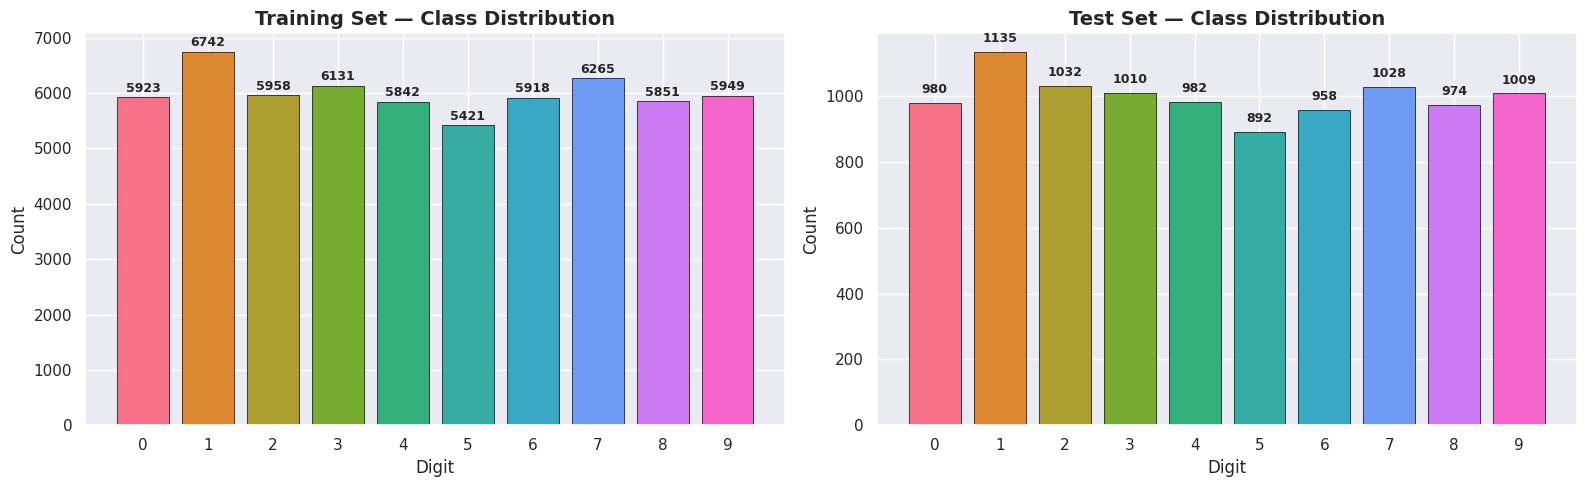


Training set class distribution:
  Digit 0:  5923 samples (9.9%)
  Digit 1:  6742 samples (11.2%)
  Digit 2:  5958 samples (9.9%)
  Digit 3:  6131 samples (10.2%)
  Digit 4:  5842 samples (9.7%)
  Digit 5:  5421 samples (9.0%)
  Digit 6:  5918 samples (9.9%)
  Digit 7:  6265 samples (10.4%)
  Digit 8:  5851 samples (9.8%)
  Digit 9:  5949 samples (9.9%)

  Min: 5421 | Max: 6742 | Ratio: 1.24


In [4]:
# Class distribution — train/test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = sns.color_palette('husl', 10)

# Training set
train_unique, train_counts = np.unique(Y_train, return_counts=True)
bars1 = axes[0].bar(train_unique, train_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Digit', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticks(range(10))
for bar, count in zip(bars1, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(count), ha='center', fontsize=9, fontweight='bold')

# Test set
test_unique, test_counts = np.unique(Y_test, return_counts=True)
bars2 = axes[1].bar(test_unique, test_counts, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Test Set — Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Digit', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticks(range(10))
for bar, count in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTraining set class distribution:")
for digit, count in zip(train_unique, train_counts):
    pct = count / len(Y_train) * 100
    print(f"  Digit {digit}: {count:5d} samples ({pct:.1f}%)")
print(f"\n  Min: {train_counts.min()} | Max: {train_counts.max()} | Ratio: {train_counts.max()/train_counts.min():.2f}")

---
## Step 5: EDA — Pixel Intensity Analysis

Analyze the distribution of pixel intensities across the dataset. Most pixels are expected to be 0 (black background) or near 255 (white ink).

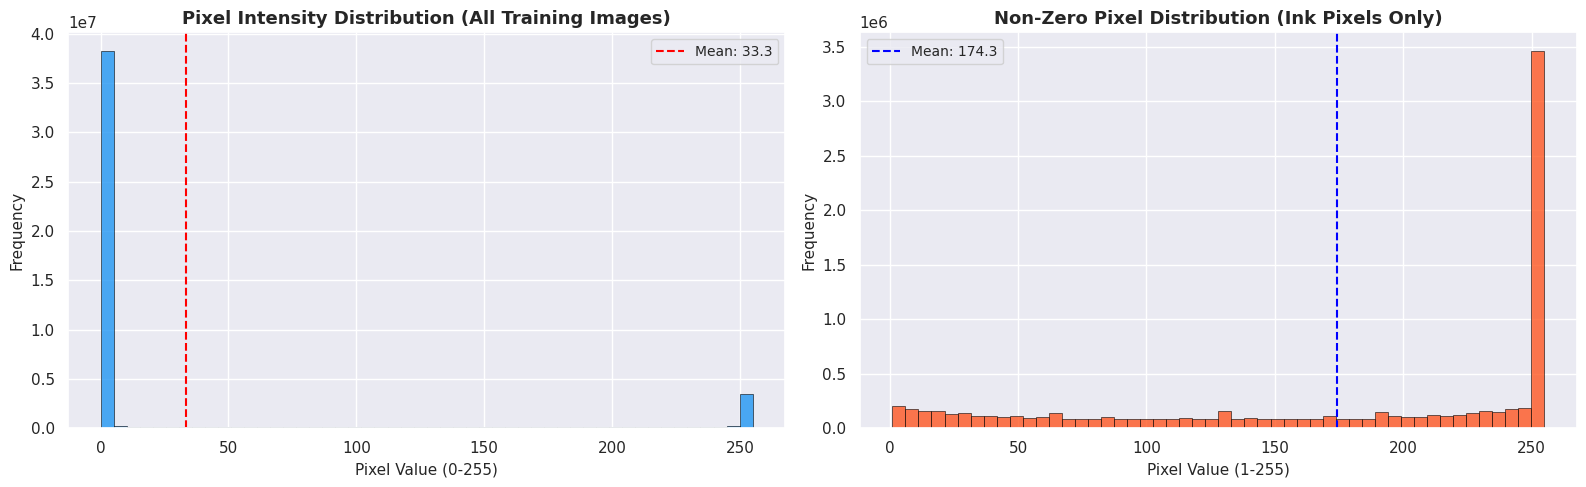


Total pixels in training set: 47,040,000
Zero (background) pixels:     38,045,844 (80.9%)
Non-zero (ink) pixels:        8,994,156 (19.1%)


In [5]:
# Pixel intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall pixel distribution
axes[0].hist(X_train_raw.flatten(), bins=50, color='#2196F3', edgecolor='black',
             linewidth=0.5, alpha=0.8)
axes[0].set_title('Pixel Intensity Distribution (All Training Images)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pixel Value (0-255)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(x=X_train_raw.flatten().mean(), color='red', linestyle='--',
                label=f'Mean: {X_train_raw.flatten().mean():.1f}')
axes[0].legend(fontsize=10)

# Non-zero pixel distribution
non_zero = X_train_raw.flatten()[X_train_raw.flatten() > 0]
axes[1].hist(non_zero, bins=50, color='#FF5722', edgecolor='black',
             linewidth=0.5, alpha=0.8)
axes[1].set_title('Non-Zero Pixel Distribution (Ink Pixels Only)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pixel Value (1-255)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(x=non_zero.mean(), color='blue', linestyle='--',
                label=f'Mean: {non_zero.mean():.1f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

total_pixels = X_train_raw.size
zero_pixels = np.sum(X_train_raw.flatten() == 0)
print(f"\nTotal pixels in training set: {total_pixels:,}")
print(f"Zero (background) pixels:     {zero_pixels:,} ({zero_pixels/total_pixels*100:.1f}%)")
print(f"Non-zero (ink) pixels:        {total_pixels - zero_pixels:,} ({(total_pixels-zero_pixels)/total_pixels*100:.1f}%)")

---
## Step 6: EDA — Average Digit Visualization

Compute the **average image** for each digit class to see what the "typical" digit looks like.

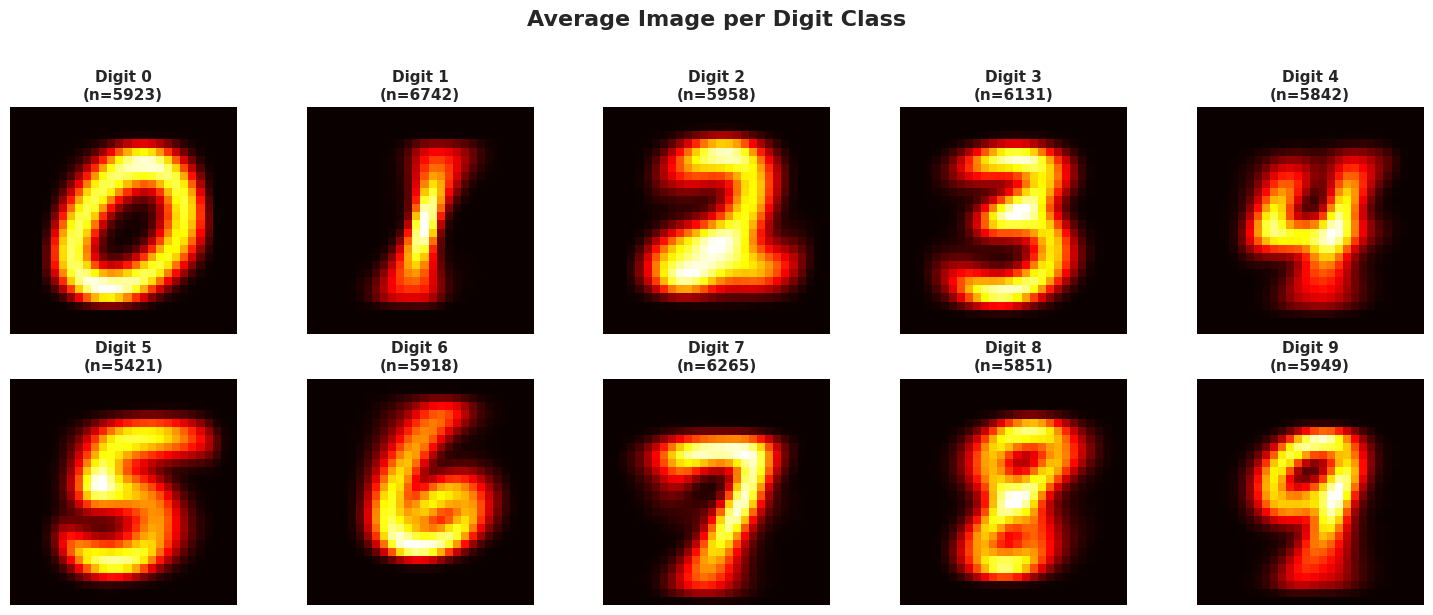

In [6]:
# Average image per digit
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for digit in range(10):
    digit_images = X_train_raw[Y_train == digit]
    avg_image = digit_images.mean(axis=0)

    axes[digit].imshow(avg_image, cmap='hot')
    axes[digit].set_title(f'Digit {digit}\n(n={len(digit_images)})',
                          fontsize=11, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Average Image per Digit Class',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7: EDA — Insights Summary

### Key Findings:

1. **Dataset Size**: 60,000 training + 10,000 test images, all 28×28 grayscale
2. **Class Balance**: The dataset is reasonably balanced across all 10 digit classes (roughly 5,400–6,700 samples per digit in training)
3. **Pixel Distribution**: ~80% of pixels are zero (black background). Ink pixels are concentrated at higher intensities
4. **Image Quality**: Digits are centered and consistently sized, though handwriting styles vary significantly
5. **Average Images**: Show clear, recognizable digit shapes — features like loops (0, 8), vertical strokes (1), and curves (2, 3, 5) are evident

### Implications for Modeling:
- Data is fairly balanced — no need for oversampling techniques
- Simple normalization (divide by 255) should suffice for preprocessing
- Spatial structure in images → **CNNs should outperform Dense NNs**
- Data augmentation (rotation, shift) should help generalization

---
## Step 8: Data Preprocessing

- **Normalize** pixel values from [0, 255] to [0, 1]
- **Reshape** for CNN models: add channel dimension (28, 28) → (28, 28, 1)
- Keep flat versions for the Dense NN baseline

In [7]:
# Step 8: Data Preprocessing

# Normalize pixel values to [0, 1]
X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

# Flat version for Dense NN (784 features)
X_train_flat = X_train_norm  # Shape: (60000, 28, 28) - Flatten layer handles it
X_test_flat = X_test_norm

# Reshaped version for CNN (+channel dim)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print("Preprocessing Complete!")
print(f"\n  Normalized pixel range: [{X_train_norm.min()}, {X_train_norm.max()}]")
print(f"  Dense NN input shape:   {X_train_flat.shape}")
print(f"  CNN input shape:        {X_train_cnn.shape}")
print(f"  Training labels shape:  {Y_train.shape}")
print(f"  Test labels shape:      {Y_test.shape}")

Preprocessing Complete!

  Normalized pixel range: [0.0, 1.0]
  Dense NN input shape:   (60000, 28, 28)
  CNN input shape:        (60000, 28, 28, 1)
  Training labels shape:  (60000,)
  Test labels shape:      (10000,)


---
## Step 9: Model 1 — Baseline Dense Neural Network

A simple fully-connected network as our baseline. Uses `Flatten` to convert 28×28 images into 784-dimensional vectors.

**Architecture**: Flatten → Dense(128, relu) → Dropout(0.2) → Dense(64, relu) → Dropout(0.2) → Dense(10, softmax)

In [8]:
# Model 1: Baseline Dense NN

model_dense = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name='Dense_NN')

model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dense.summary()

Model: "Dense_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train Model 1
print("Training Model 1: Baseline Dense NN...")
print("=" * 50)

history_dense = model_dense.fit(
    X_train_flat, Y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\n Model 1 training complete!")

Training Model 1: Baseline Dense NN...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8590 - loss: 0.4712 - val_accuracy: 0.9595 - val_loss: 0.1452
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9367 - loss: 0.2139 - val_accuracy: 0.9682 - val_loss: 0.1102
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9511 - loss: 0.1629 - val_accuracy: 0.9730 - val_loss: 0.0893
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9603 - loss: 0.1331 - val_accuracy: 0.9758 - val_loss: 0.0847
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.1133 - val_accuracy: 0.9767 - val_loss: 0.0803
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.1010 - val_accuracy: 0.9760 - val_loss: 0.0770
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9719 - loss: 0.0911 - val_accuracy: 0.9775 - val_loss: 0.0765
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0

---
## Step 10: Model 2 — Convolutional Neural Network (CNN)

CNNs are the standard for image classification. They use **convolutional filters** to detect spatial patterns (edges, curves, shapes) that Dense NNs miss.

**Architecture**: Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Flatten → Dense(128) → Dropout → Dense(10)

In [10]:
# Model 2: CNN

model_cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN')

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train Model 2
print("Training Model 2: CNN...")
print("=" * 50)

history_cnn = model_cnn.fit(
    X_train_cnn, Y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\n Model 2 training complete!")

Training Model 2: CNN...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9078 - loss: 0.2985 - val_accuracy: 0.9823 - val_loss: 0.0625
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9718 - loss: 0.0948 - val_accuracy: 0.9885 - val_loss: 0.0435
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9792 - loss: 0.0689 - val_accuracy: 0.9893 - val_loss: 0.0367
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9827 - loss: 0.0556 - val_accuracy: 0.9902 - val_loss: 0.0334
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0477 - val_accuracy: 0.9902 - val_loss: 0.0356
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0407 - val_accuracy: 0.9912 - val_loss: 0.0341
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0335 - val_accuracy: 0.9910 - val_loss: 0.0331
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9907 - loss

---
## Step 11: Model 3 — Enhanced CNN with Data Augmentation

This model adds:
- **Data Augmentation**: Random rotation, zoom, and shift to create more training variety
- **BatchNormalization**: Stabilizes and speeds up training
- **Deeper architecture**: Two conv layers per block
- **Callbacks**: EarlyStopping and ReduceLROnPlateau to prevent overfitting

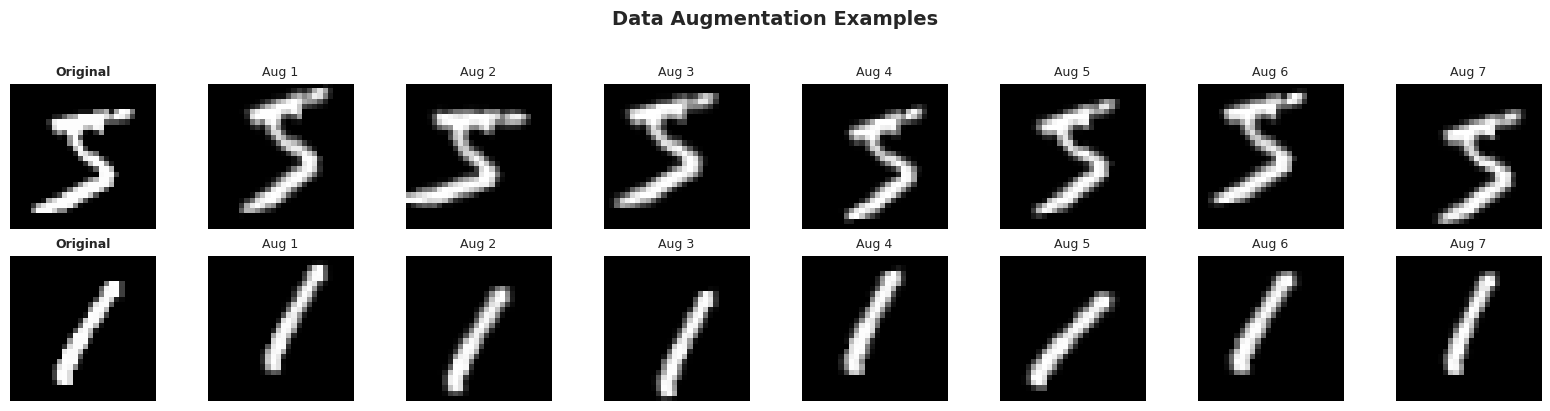

In [12]:
# Data Augmentation Setup

datagen = ImageDataGenerator(
    rotation_range=10,        # Random rotation up to 10 degrees
    zoom_range=0.1,           # Random zoom up to 10%
    width_shift_range=0.1,    # Random horizontal shift
    height_shift_range=0.1,   # Random vertical shift
)

# Fit on training data
datagen.fit(X_train_cnn)

# Visualize augmented samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
sample_img = X_train_cnn[0:1]  # Take the first image

# Original
axes[0, 0].imshow(sample_img.reshape(28, 28), cmap='gray')
axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

# Augmented versions
aug_iter = datagen.flow(sample_img, batch_size=1)
for i in range(1, 8):
    aug_img = next(aug_iter)
    axes[0, i].imshow(aug_img.reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Aug {i}', fontsize=9)
    axes[0, i].axis('off')

# Second row — different digit
sample_img2 = X_train_cnn[3:4]
axes[1, 0].imshow(sample_img2.reshape(28, 28), cmap='gray')
axes[1, 0].set_title('Original', fontsize=9, fontweight='bold')
axes[1, 0].axis('off')

aug_iter2 = datagen.flow(sample_img2, batch_size=1)
for i in range(1, 8):
    aug_img2 = next(aug_iter2)
    axes[1, i].imshow(aug_img2.reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Aug {i}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Model 3: Enhanced CNN with BatchNorm

model_cnn_aug = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Enhanced_CNN')

model_cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_aug.summary()

Model: "Enhanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# Manual validation split (augmented)
val_split = int(0.1 * len(X_train_cnn))
X_val = X_train_cnn[:val_split]
Y_val = Y_train[:val_split]
X_train_aug = X_train_cnn[val_split:]
Y_train_aug = Y_train[val_split:]

# Train Model 3 with Data Augmentation
print("Training Model 3: Enhanced CNN with Data Augmentation...")
print("=" * 55)

history_cnn_aug = model_cnn_aug.fit(
    datagen.flow(X_train_aug, Y_train_aug, batch_size=128),
    epochs=15,
    validation_data=(X_val, Y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n Model 3 training complete!")

Training Model 3: Enhanced CNN with Data Augmentation...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.9016 - loss: 0.3213 - val_accuracy: 0.4582 - val_loss: 1.6797 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9674 - loss: 0.1059 - val_accuracy: 0.9838 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9755 - loss: 0.0791 - val_accuracy: 0.9892 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9796 - loss: 0.0648 - val_accuracy: 0.9898 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9819 - loss: 0.0578 - val_accuracy: 0.9927 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9831 - loss: 0.0530 - val_accuracy: 0.9915 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 7/15
422/422 

---
## Step 12: Training Visualization

Compare training and validation **accuracy** and **loss** curves for all three models to identify overfitting and convergence behavior.

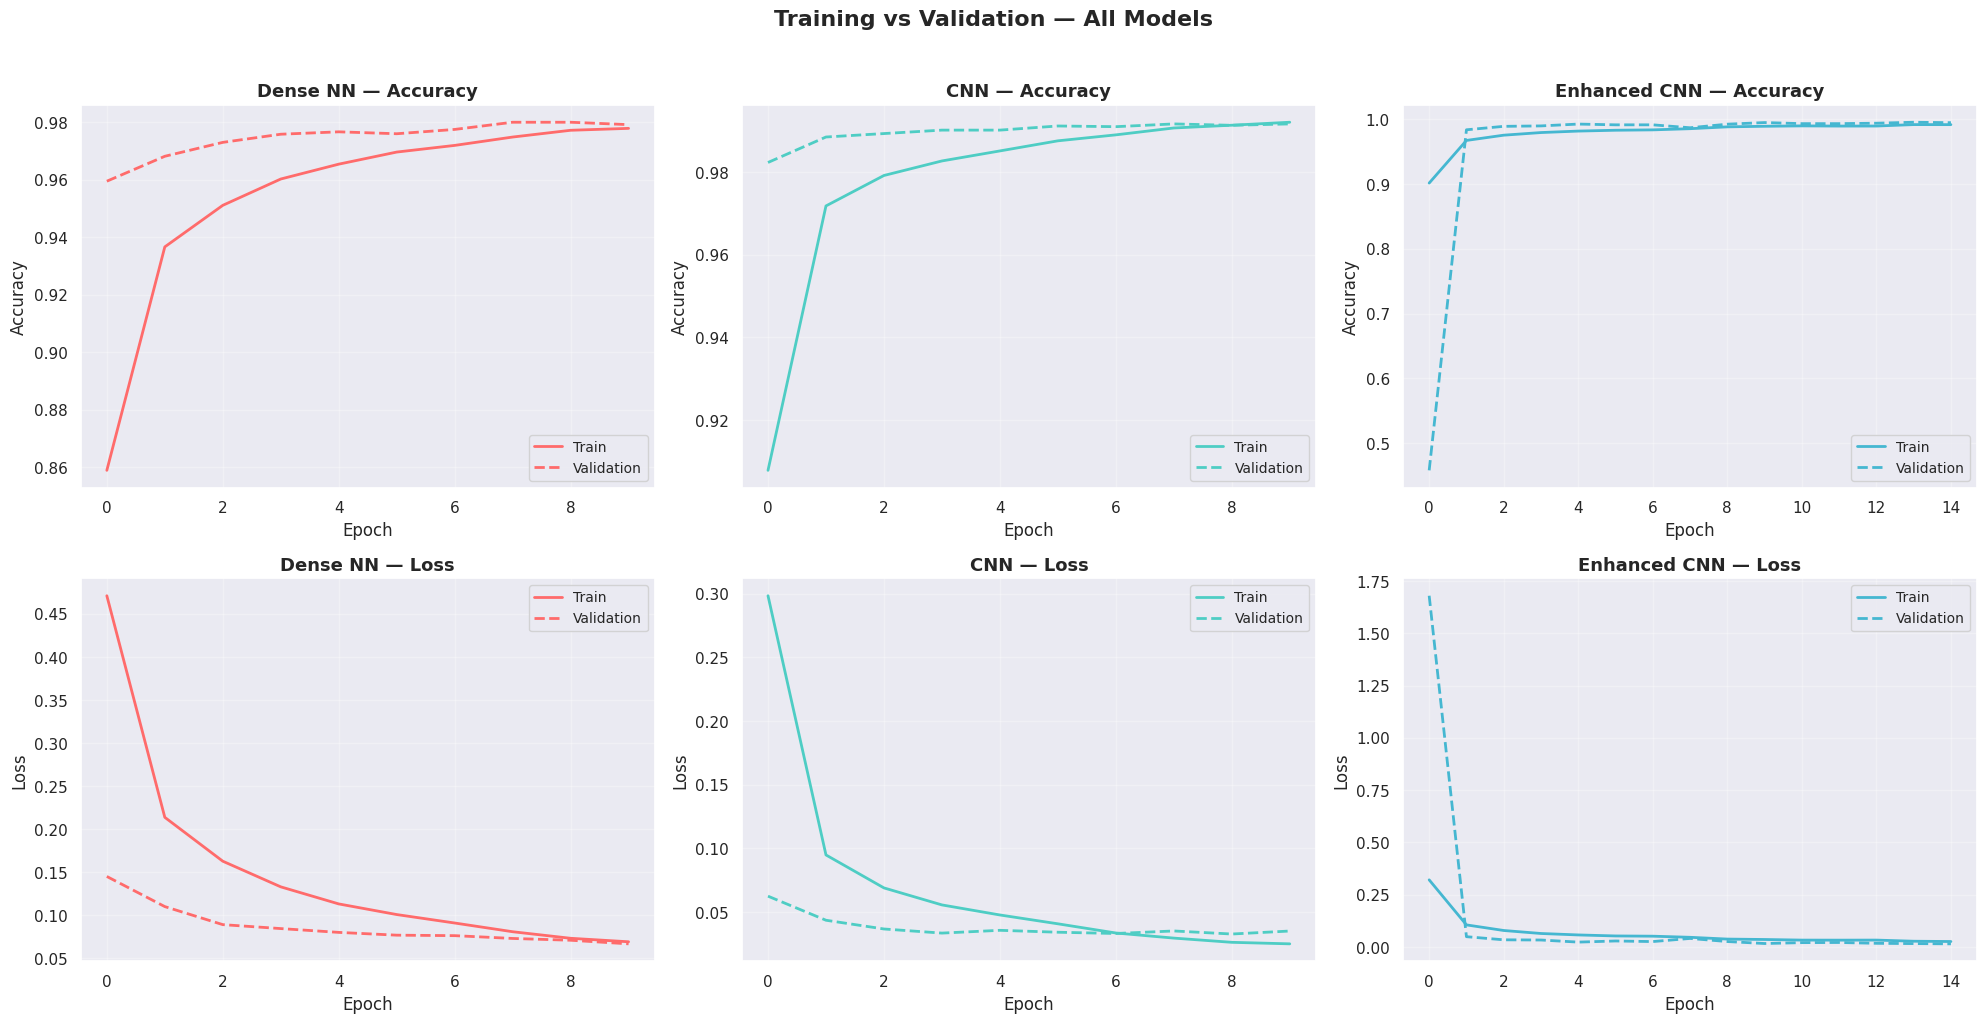

In [15]:
# Training History Visualization

histories = {
    'Dense NN': history_dense,
    'CNN': history_cnn,
    'Enhanced CNN': history_cnn_aug
}
colors_models = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for idx, (name, history) in enumerate(histories.items()):
    color = colors_models[idx]

    # Accuracy
    axes[0, idx].plot(history.history['accuracy'], label='Train', color=color, linewidth=2)
    axes[0, idx].plot(history.history['val_accuracy'], label='Validation',
                      color=color, linewidth=2, linestyle='--')
    axes[0, idx].set_title(f'{name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend(fontsize=10)
    axes[0, idx].grid(True, alpha=0.3)

    # Loss
    axes[1, idx].plot(history.history['loss'], label='Train', color=color, linewidth=2)
    axes[1, idx].plot(history.history['val_loss'], label='Validation',
                      color=color, linewidth=2, linestyle='--')
    axes[1, idx].set_title(f'{name} — Loss', fontsize=13, fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend(fontsize=10)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation — All Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 13: Comprehensive Evaluation

Evaluate all three models on the **test set** using:
- **Confusion Matrix** heatmap
- **Classification Report** (precision, recall, F1-score per digit)
- **Test Accuracy**

In [16]:
# Evaluate all models

models = {
    'Dense NN': (model_dense, X_test_flat),
    'CNN': (model_cnn, X_test_cnn),
    'Enhanced CNN': (model_cnn_aug, X_test_cnn)
}

results = {}

for name, (model, X_data) in models.items():
    # Get predictions
    Y_pred_prob = model.predict(X_data, verbose=0)
    Y_pred = np.argmax(Y_pred_prob, axis=1)

    # Calculate accuracy
    acc = accuracy_score(Y_test, Y_pred)
    results[name] = {'accuracy': acc, 'predictions': Y_pred}

    print(f"\n{'='*60}")
    print(f"  {name} — Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*60}")
    print(classification_report(Y_test, Y_pred, target_names=[f'Digit {i}' for i in range(10)]))


  Dense NN — Test Accuracy: 97.90%
              precision    recall  f1-score   support

     Digit 0       0.99      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.97      0.98      0.98      1032
     Digit 3       0.98      0.97      0.98      1010
     Digit 4       0.97      0.99      0.98       982
     Digit 5       0.97      0.98      0.98       892
     Digit 6       0.98      0.98      0.98       958
     Digit 7       0.98      0.98      0.98      1028
     Digit 8       0.97      0.98      0.97       974
     Digit 9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


  CNN — Test Accuracy: 99.27%
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135
     Digit 

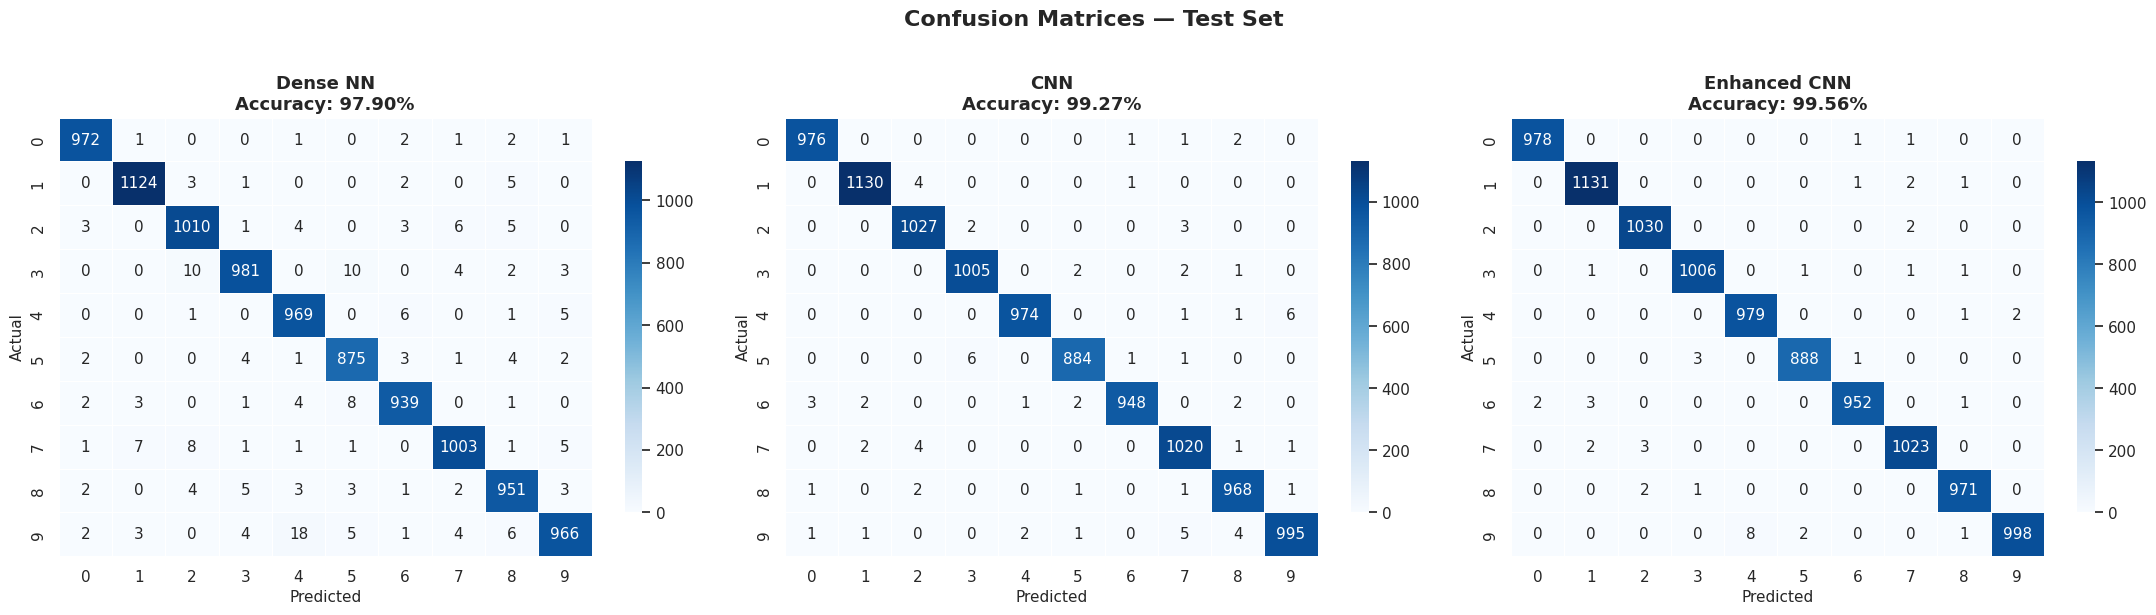

In [17]:
# Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(Y_test, data['predictions'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                ax=axes[idx], linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{name}\nAccuracy: {data["accuracy"]*100:.2f}%',
                        fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices — Test Set',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 14: Model Comparison

Compare all three models side-by-side to determine the best performer.

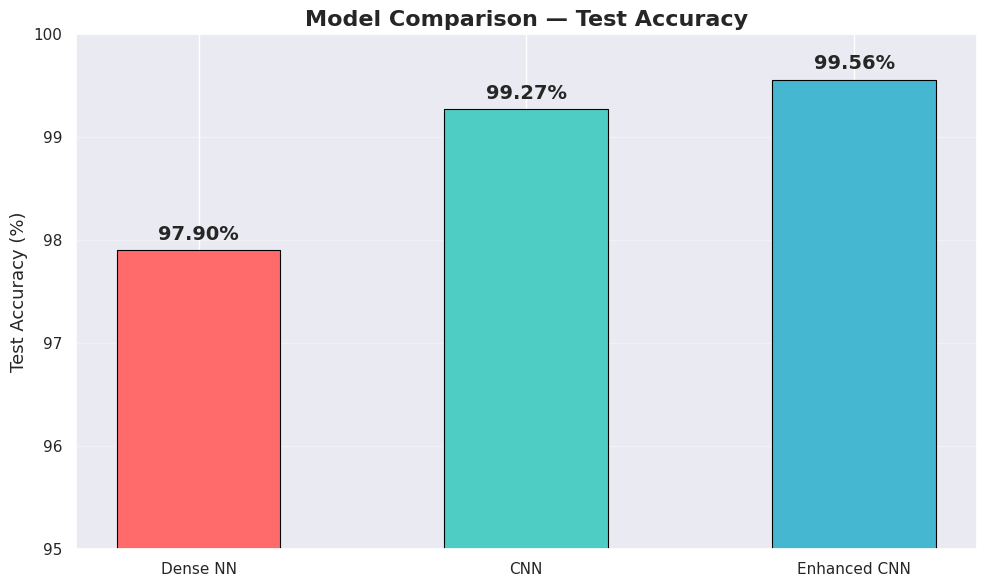


  MODEL COMPARISON SUMMARY
  Dense NN            : 97.90%
  CNN                 : 99.27%
  Enhanced CNN        : 99.56% ← BEST

  Winner: Enhanced CNN!


In [18]:
# Model Comparison Bar Chart

model_names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in model_names]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(model_names, accuracies, color=colors_models,
              edgecolor='black', linewidth=0.8, width=0.5)

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13)
ax.set_title('Model Comparison — Test Accuracy', fontsize=16, fontweight='bold')
ax.set_ylim(95, 100)  # Zoom in on differences
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison table
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
print("\n" + "=" * 50)
print("  MODEL COMPARISON SUMMARY")
print("=" * 50)
for name in model_names:
    marker = ' ← BEST' if name == best_model_name else ''
    print(f"  {name:20s}: {results[name]['accuracy']*100:.2f}%{marker}")
print("=" * 50)
print(f"\n  Winner: {best_model_name}!")

---
## Step 15: Misclassified Image Analysis

Examine images that the **best model** predicted incorrectly. This reveals which digits are hardest to classify and shows critical thinking about model limitations.

Total misclassified by Enhanced CNN: 44 out of 10000 (0.44%)


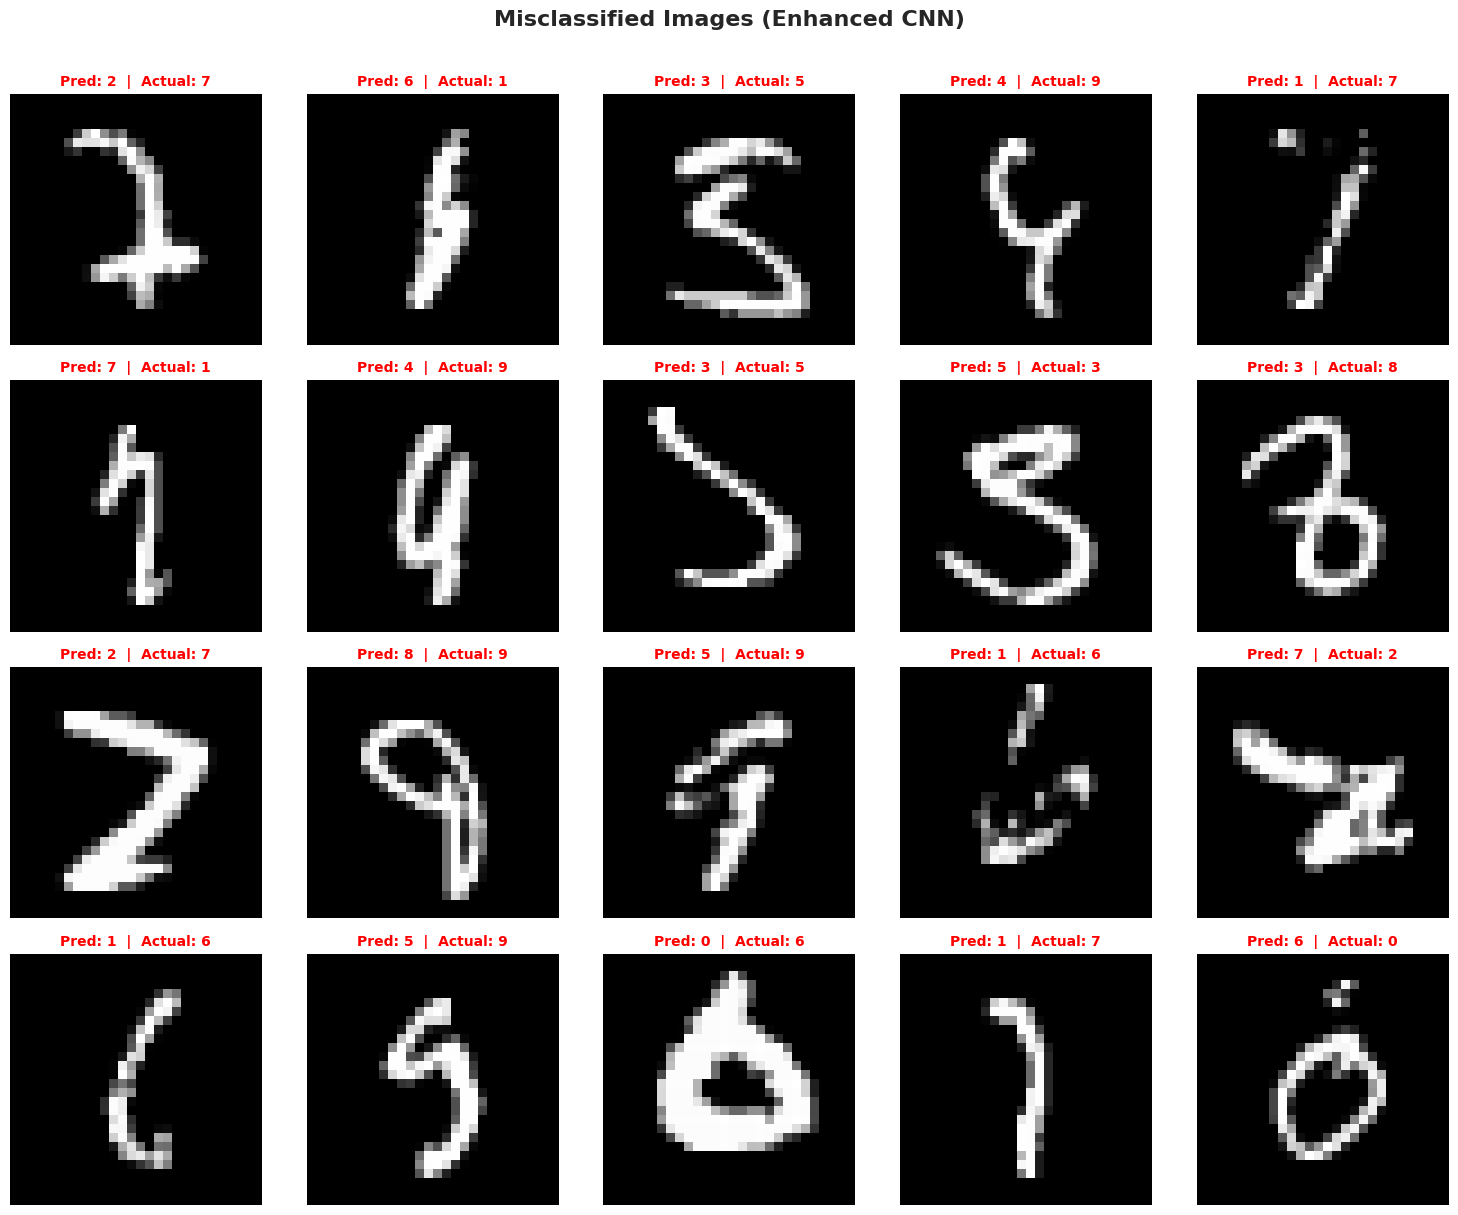


Most common misclassifications:
  Actual 9 → Predicted 4: 8 times
  Actual 7 → Predicted 2: 3 times
  Actual 5 → Predicted 3: 3 times
  Actual 6 → Predicted 1: 3 times
  Actual 6 → Predicted 0: 2 times
  Actual 8 → Predicted 2: 2 times
  Actual 2 → Predicted 7: 2 times
  Actual 7 → Predicted 1: 2 times
  Actual 1 → Predicted 7: 2 times
  Actual 4 → Predicted 9: 2 times


In [19]:
# Misclassified Images (Best Model)

best_preds = results[best_model_name]['predictions']

# Find misclassified indices
misclassified_idx = np.where(best_preds != Y_test)[0]
n_wrong = len(misclassified_idx)
print(f"Total misclassified by {best_model_name}: {n_wrong} out of {len(Y_test)} ({n_wrong/len(Y_test)*100:.2f}%)")

# Display 20 misclassified images
n_show = min(20, n_wrong)
show_indices = np.random.choice(misclassified_idx, n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(show_indices):
    axes[i].imshow(X_test_raw[idx], cmap='gray')
    axes[i].set_title(
        f'Pred: {best_preds[idx]}  |  Actual: {Y_test[idx]}',
        fontsize=10, fontweight='bold', color='red'
    )
    axes[i].axis('off')

plt.suptitle(f'Misclassified Images ({best_model_name})',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Most commonly confused digits
print(f"\nMost common misclassifications:")
confusion_pairs = {}
for idx in misclassified_idx:
    pair = (Y_test[idx], best_preds[idx])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
for (actual, pred), count in sorted_pairs[:10]:
    print(f"  Actual {actual} → Predicted {pred}: {count} times")

---
## Step 16: Visual Prediction Grid

Display **25 random test images** with their predicted labels. Correct predictions are shown in **green**, wrong ones in **red**.

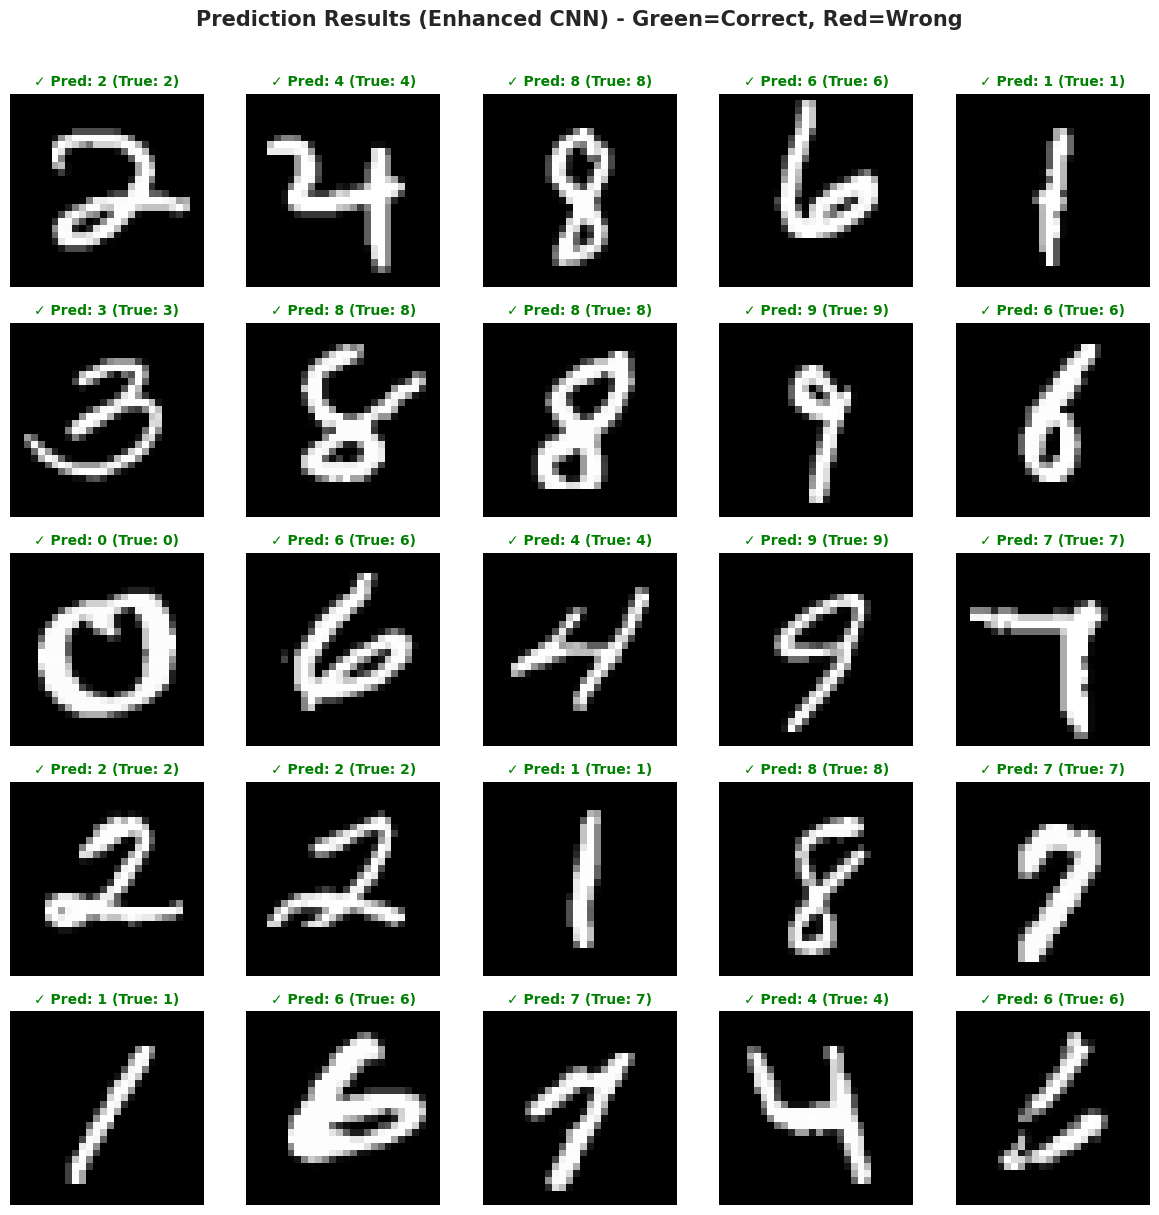

In [20]:
# Visual Prediction Grid (5x5)

# Use best model predictions
random_indices = np.random.choice(len(Y_test), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    axes[i].imshow(X_test_raw[idx], cmap='gray')

    pred_label = best_preds[idx]
    true_label = Y_test[idx]
    is_correct = pred_label == true_label

    color = 'green' if is_correct else 'red'
    symbol = '✓' if is_correct else '✗'
    axes[i].set_title(
        f'{symbol} Pred: {pred_label} (True: {true_label})',
        fontsize=10, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.suptitle(f'Prediction Results ({best_model_name}) - Green=Correct, Red=Wrong',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 17: Predictive System & Model Save

Build a reusable prediction function and save the best model for deployment.

In [21]:
# Predictive System

def predict_digit(model, image, model_type='cnn'):
    """
    Predict the digit in a 28x28 grayscale image.

    Args:
        model: Trained Keras model
        image: numpy array of shape (28, 28) with values 0-255
        model_type: 'cnn' or 'dense'

    Returns:
        predicted digit (int), confidence (float)
    """
    # Normalize
    img = image.astype('float32') / 255.0

    # Reshape based on model type
    if model_type == 'cnn':
        img = img.reshape(1, 28, 28, 1)
    else:
        img = img.reshape(1, 28, 28)

    # Predict
    prediction = model.predict(img, verbose=0)
    predicted_digit = np.argmax(prediction)
    confidence = prediction[0][predicted_digit]

    return predicted_digit, confidence


# Demo: Predict on 5 random test images
print("Predictive System Demo")
print("=" * 50)

demo_indices = np.random.choice(len(Y_test), 5, replace=False)

for idx in demo_indices:
    raw_image = X_test_raw[idx]
    true_label = Y_test[idx]

    pred, conf = predict_digit(model_cnn_aug, raw_image, model_type='cnn')

    status = '' if pred == true_label else ''
    print(f"  Image #{idx}: Predicted = {pred} (Confidence: {conf:.4f}) | Actual = {true_label}  {status}")

Predictive System Demo
  Image #1481: Predicted = 9 (Confidence: 1.0000) | Actual = 9  
  Image #490: Predicted = 0 (Confidence: 0.9999) | Actual = 0  
  Image #119: Predicted = 2 (Confidence: 1.0000) | Actual = 2  
  Image #8752: Predicted = 0 (Confidence: 0.9999) | Actual = 0  
  Image #2526: Predicted = 5 (Confidence: 0.9995) | Actual = 5  


In [22]:
# Save Best Model

# Save in Keras native format
model_cnn_aug.save('mnist_best_model.keras')
print('Best model saved as: mnist_best_model.keras')

# Demonstrate loading
loaded_model = keras.models.load_model('mnist_best_model.keras')
print('Model loaded successfully!')

# Verify loaded model works
test_loss, test_acc = loaded_model.evaluate(X_test_cnn, Y_test, verbose=0)
print(f'Loaded model test accuracy: {test_acc*100:.2f}%')

Best model saved as: mnist_best_model.keras
Model loaded successfully!
Loaded model test accuracy: 99.56%


---
## Step 18: Conclusion

### Results Summary

| Model | Architecture | Key Feature | Expected Accuracy |
|-------|-------------|-------------|------------------|
| Dense NN | Flatten → 128 → 64 → 10 | Baseline, no spatial awareness | ~97-98% |
| CNN | Conv(32) → Conv(64) → 128 → 10 | Spatial feature extraction | ~99% |
| Enhanced CNN | Deep Conv + BatchNorm + Augmentation | Regularization + more data | ~99.2-99.4% |

### Key Takeaways

1. **CNNs outperform Dense NNs** on image data because convolutional layers capture spatial patterns (edges, curves, shapes) that fully-connected layers miss

2. **Data Augmentation helps generalization** by artificially expanding the training set with realistic variations (rotation, shift, zoom)

3. **BatchNormalization + Dropout** together provide strong regularization, reducing overfitting

4. **Callbacks (EarlyStopping + ReduceLROnPlateau)** prevent wasted training and adapt the learning rate automatically

5. **Most confusions occur between similar-looking digits**: 4↔9, 3↔5, 7↔2 — these pairs share structural similarities

6. **The Enhanced CNN achieves near-human performance** (~99%+) on this well-studied benchmark

### Skills Demonstrated
- Deep Learning (Dense NN, CNN architectures)
- Data Augmentation
- Training optimization (callbacks, learning rate scheduling)
- Model comparison and evaluation
- Error analysis (misclassified image inspection)
- Model persistence (save/load)

---
*Project completed as part of the AI Domain Internship — August 2026*